In [1]:
# ¿Cómo podemos clasificar imágenes de dígitos escritos a mano y revisar la incertidumbre de cada predicción?

import json
import pickle

import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# Se cargan imágenes etiquetadas de dígitos para construir un clasificador.

digits = datasets.load_digits()

In [3]:
# ¿Cuántas imágenes y píxeles están disponibles para entrenar el clasificador?

digits.images.shape

(1797, 8, 8)

In [4]:
# Una imagen es una matriz de intensidades numéricas.

digits.images[0, :, :]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [5]:
# ¿Qué dígitos debe distinguir el modelo?

set(digits.target)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

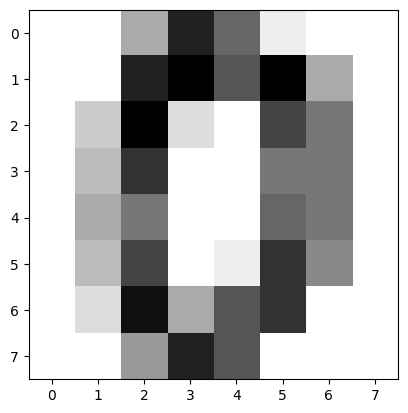

In [6]:
# Se visualiza cómo se ve una matriz de píxeles para una persona.

plt.figure()
plt.imshow(digits.images[0], cmap=plt.cm.binary)
plt.grid(False)
plt.show()

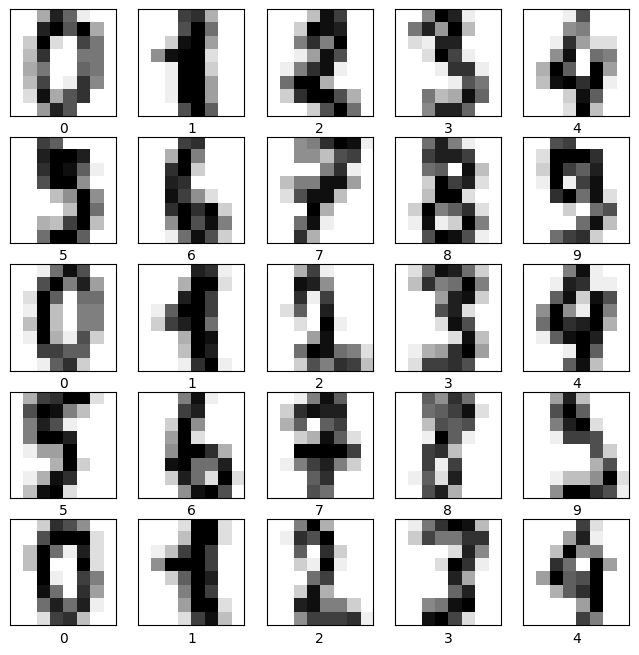

In [7]:
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(digits.images[i], cmap=plt.cm.binary)
    plt.xlabel(digits.target[i])
plt.show()

In [8]:
# Cada imagen se representa como un vector de intensidades; así X almacena un ejemplo por fila y un píxel por columna.
#
# X
# ├── filas: imágenes (ejemplos)
# └── columnas: intensidades de píxel (features)

n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
data.shape

(1797, 64)

In [9]:
# Se reservan imágenes de cada dígito para evaluar predicciones sobre datos no vistos.

X_train, X_test, y_train, y_test = train_test_split(
    data,
    digits.target,
    test_size=0.5,
    random_state=0,
    stratify=digits.target,
)

In [10]:
# Se ajusta un clasificador que asigna una probabilidad a cada dígito posible.

estimator = LogisticRegression(max_iter=1000)

estimator.fit(
    X_train,
    y_train,
)

# ¿La precisión de entrenamiento es consistente con la de prueba?
accuracy_score(y_true=y_train, y_pred=estimator.predict(X_train))

1.0

In [11]:
# Se calculan las probabilidades por clase y la precisión sobre las imágenes reservadas.

predictions = estimator.predict(X_test)
predicted_proba = estimator.predict_proba(X_test)

accuracy_score(y_true=y_test, y_pred=predictions)

0.9577308120133482

Confusion matrix:
[[88  0  0  0  1  0  0  0  0  0]
 [ 0 88  0  0  1  0  0  0  1  1]
 [ 0  1 86  1  0  0  0  0  0  0]
 [ 0  0  0 88  0  1  0  0  1  2]
 [ 0  2  0  0 88  0  0  0  1  0]
 [ 0  0  1  2  0 84  1  2  1  0]
 [ 0  2  0  0  1  1 86  0  1  0]
 [ 0  0  0  0  1  0  0 86  0  2]
 [ 0  4  3  0  0  0  0  0 79  1]
 [ 0  0  0  0  0  1  0  0  1 88]]


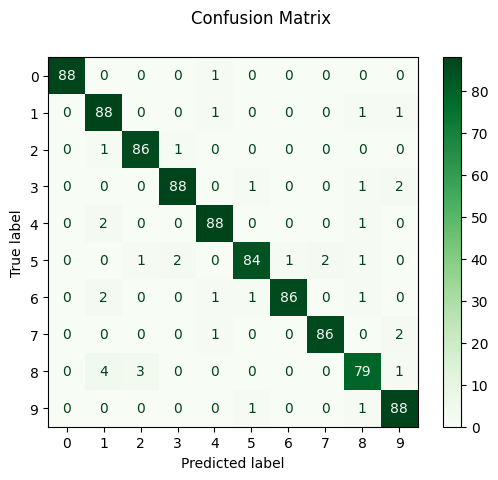

In [12]:
# ¿Qué dígitos se confunden y qué revela eso sobre los errores del clasificador?

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Greens",
)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

In [13]:
# Se contrasta la etiqueta predicha, su probabilidad y la imagen real en casos concretos.


def plot_image(i, predicted_label, true_label, predicted_proba, img):

    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    #
    plt.imshow(img, cmap=plt.cm.binary)

    if predicted_label[i] == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel(
        "{} {:2.0f}% ({})".format(
            predicted_label[i],
            100 * max(predicted_proba[i, :]),
            true_label,
        ),
        color=color,
    )


def plot_value_array(i, predicted_proba, predicted_label, true_label):
    #
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predicted_proba[i, :], color="#777777")
    plt.ylim([0, 1])
    #
    thisplot[predicted_label[i]].set_color("red")
    thisplot[true_label[i]].set_color("blue")

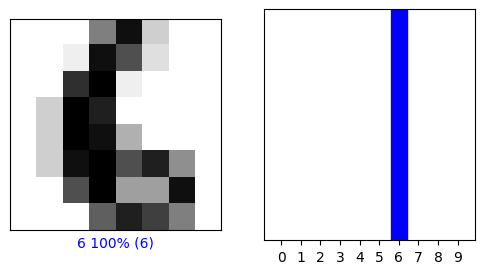

In [14]:
i = 0
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_image(
    i,
    predictions,
    y_test,
    predicted_proba,
    X_test.reshape(len(X_test), 8, 8),
)
plt.subplot(1, 2, 2)
plot_value_array(
    i,
    predicted_proba,
    predictions,
    y_test,
)
plt.show()

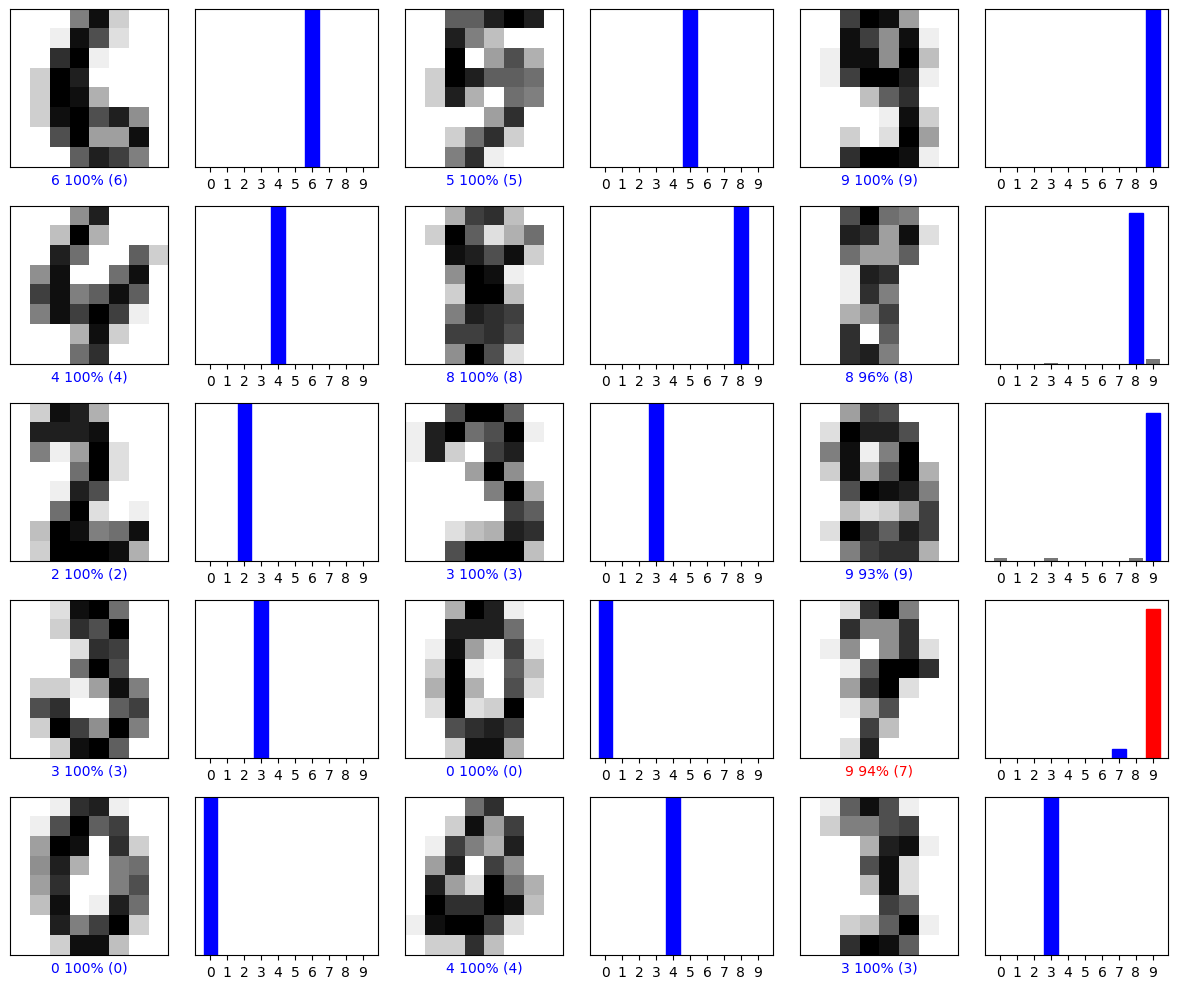

In [15]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(
        i,
        predictions,
        y_test,
        predicted_proba,
        X_test.reshape(len(X_test), 8, 8),
    )
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(
        i,
        predicted_proba,
        predictions,
        y_test,
    )
plt.tight_layout()
plt.show()

In [16]:
# Se guardan el clasificador y sus métricas de prueba como evidencia verificable.

with open("../submission/estimator.pkl", "wb") as file:
    pickle.dump(estimator, file)

metrics = {
    "test_accuracy": accuracy_score(y_true=y_test, y_pred=predictions),
    "test_size": len(y_test),
}

with open("../submission/metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

In [17]:
# Se comprueba que el modelo almacenado conserva sus clases y probabilidades.

with open("../submission/estimator.pkl", "rb") as file:
    new_clf = pickle.load(file)

new_predictions = new_clf.predict(X_test)
new_predicted_proba = new_clf.predict_proba(X_test)

accuracy_score(y_true=y_test, y_pred=new_predictions), new_predicted_proba[0]

(0.9577308120133482,
 array([5.80721033e-07, 4.19294941e-06, 6.61007001e-09, 2.69878611e-13,
        1.97774288e-06, 3.62252855e-12, 9.99201969e-01, 1.16828096e-12,
        7.91272609e-04, 4.85435972e-18]))